# Basic Example using MOGPTK

Fit a multi-output spectral mixture GP to a simple two-band example. Bands are similar sinusoids but with a known phase difference plus some Gaussian noise.

In [1]:
import mogptk
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#torch.manual_seed(0);

num_components = 1 # "D"

/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


The MOSM kernel has the form (Definition 5; Parra & Tobar 2017):

$$k_{ij}(\tau) = \sum_{q=1}^Q \alpha^{(q)}_{ij} \exp \left( -\frac{1}{2} (\tau + \theta^{(q)}_{ij})^\top \Sigma^{(q)}_{ij}(\tau + \theta^{(q)}_{ij}) \right) \cos \left( (\tau + \theta^{(q)}_{ij})^\top \mu^{(q)}_{ij} + \phi^{(q)}_{ij} \right), \qquad \alpha^{(q)}_{ij} = w^{(q)}_{ij} (2\pi)^{n/2} | \Sigma^{(q)}_{ij} |^{1/2} $$

- No. of spectral mixture components: $Q$
- parameter of $q$ th mixture component: $(.)^{(q)}$
- Covariance: $\Sigma_{ij}$
- Mean: $\mu_{ij}$
- Magnitude (weight of component): $w_{ij}$
- Delay: $\theta_{ij} = \theta_i - \theta_j$
- Phase: $\phi_{ij} = \phi_i - \phi_j$

**NB:** the above parameters describe the shape of the kernel in the *spectral* domain.

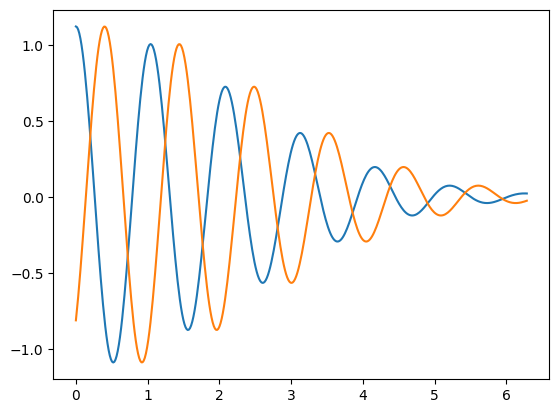

In [3]:
# Plot one-dimensional, single-component MOSM kernel in time domain
def plot_k(taus, w_mag, sigma_cov, theta_delay, mu_freq, phi_phase):
    alpha = w_mag * (2*np.pi)**0.5 * np.abs(sigma_cov)**0.5
    k = alpha*np.exp(-0.5*(taus+theta_delay)**2*sigma_cov) * np.cos( (taus+theta_delay)*mu_freq + phi_phase)

    plt.plot(taus, k)

taus = np.linspace(0, 2*np.pi, 400)
plot_k(taus, w_mag=1, sigma_cov=1/5, theta_delay=0, mu_freq=6, phi_phase=0)
plot_k(taus, w_mag=1, sigma_cov=1/5, theta_delay=-0.4, mu_freq=6, phi_phase=0)

For a MOSM GP with a single mixture component (Q = 1), the $i^\mathrm{th}$ diagonal submatrix corresponding to the $i^\mathrm{th}$ band ($i = j$, $\theta_{ii} = 0$, $\phi_{ii} = 0$) is a SE $\times$ cosine autocovariance kernel:

$$k_{ii}(\tau) = \alpha_{ii} \exp\left\{ -\frac{1}{2} \tau^\top \Sigma_{ii} \tau \right\} \cos(\tau^\top \mu_{ii})$$

where $\alpha$ is an amplitude and $\Sigma$ is a length-scale hyperparameter.

Between bands 1 and 2, the kernel is:

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} (\tau + \theta_{12})^\top \Sigma_{12} (\tau + \theta_{12}) \right\} \cos\left((\tau + \theta_{12})^\top \mu_{12} + \phi_{12}\right)$$

$$\alpha_{12} = w_{12} (2\pi)^\frac{n}{2} |\Sigma_{12}|^\frac{1}{2}$$

## Two-bands: Time delayed sinusoids

(Synthetic data generated in R and saved to .CSV)

For a generic sinusoid:

$$y(t) = \textrm{A} \sin \left(2 \pi f [t - \theta] + \phi\right)$$

### Synthetic dataset

$$f_1 \sim \mathcal{N}(2.0 \sin(2\pi(0.7)[t - 0.0] + 0.0), 0.15^2)$$
$$f_2 \sim \mathcal{N}(2.0 \sin(2\pi (0.7)[t - 0.4] + 0.0), 0.15^2)$$


- Two noisy sinusoidal signals:
    - same frequency, $f = 0.7$ cycles/s, or $\omega = 2\pi \times 0.7 = 1.4\pi$ radians/s,
    - same amplitude $A = 2.0$, 
    - second band is delayed by $\theta_{12} = \theta_1 - \theta_2 = 0.4$ radians.
    - no difference in phases $\phi_{12} = \phi_1 = \phi_2 = 0$ radians.
- Both bands with added Gaussian noise ($\sigma_\varepsilon = 0.15$).
- Both bands with 20\% of data points removed randomly.



Expect to see the second waveform shifted in time by $\theta_{12}$.

Cross-covariance of observations $\tau$ seconds apart, between bands 1 and 2 if $\theta_{12} = 0$ and $\phi_{12} \ne 0$ (fixed delay parameter):

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \Sigma_{12} \tau^2 \right\} \cos\left(\mu_{12}\tau + \phi_{12}\right)$$

or if $\phi_{12} = 0$ and $\theta_{12} \ne 0$ (fixed phase parameter):

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \Sigma_{12} (\tau + \theta_{12})^2 \right\} \cos\left( \mu_{12}(\tau + \theta_{12})\right)$$

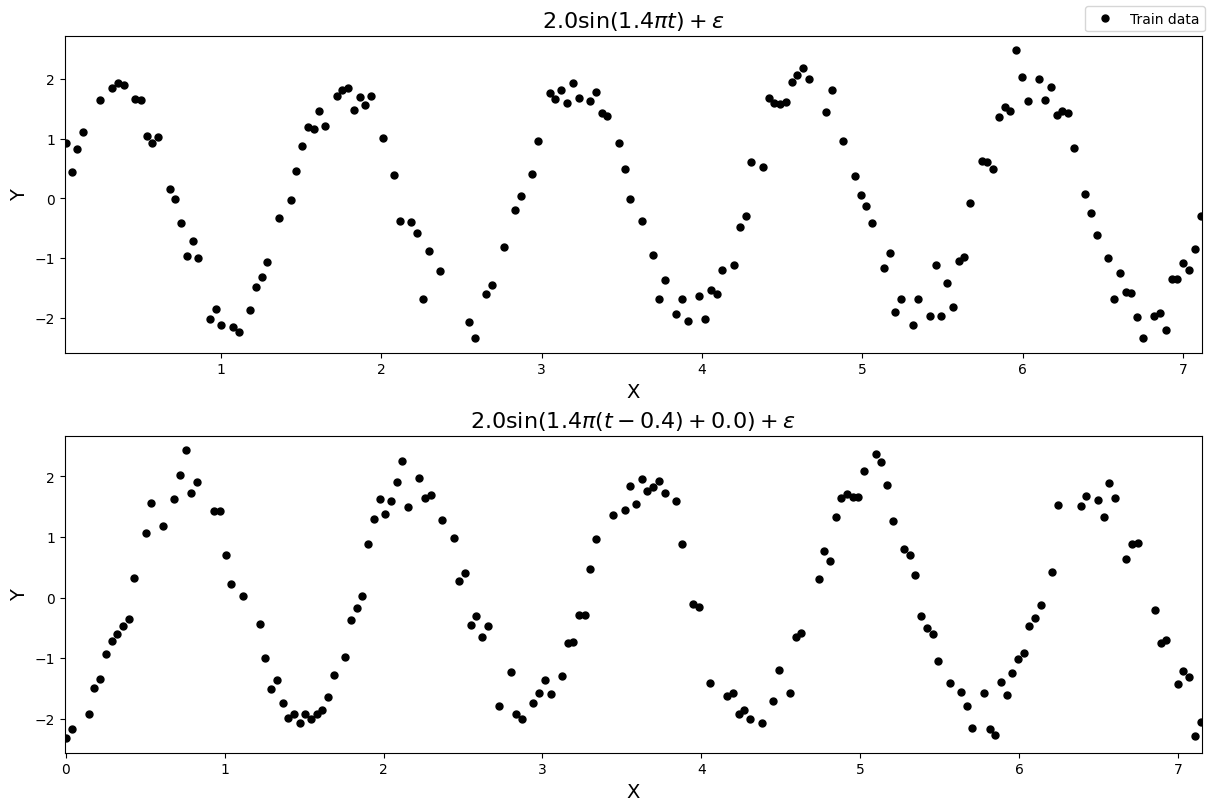

In [4]:
# Known values from synthetic data generated in R
num_bands = 2
amplitude = 2.0
noise_sigma = 0.25

frequency = 0.7 # cycles/s
omega = 2*np.pi*frequency # radians/s
delay = 0.4 # radians
phase = 0.0

sinusoid_df = pd.read_csv('mcar_sinusoid.csv')
band1_df = sinusoid_df.query('d == 1')
band2_df = sinusoid_df.query('d == 2')

dataset1 = mogptk.DataSet(
    mogptk.Data(X=band1_df['t'], Y=band1_df['y'], name=rf'${amplitude} \sin({2*frequency}\pi t) + \varepsilon$'),
    mogptk.Data(X=band2_df['t'], Y=band2_df['y'], name=rf'${amplitude} \sin({2*frequency}\pi (t - {delay}) + {phase}) + \varepsilon$')
)

dataset1.plot();

### Power Spectrum

Knowing the mathematical expression for the synthetic data, we see the expected peak at $f = 0.5$ in the periodogram.

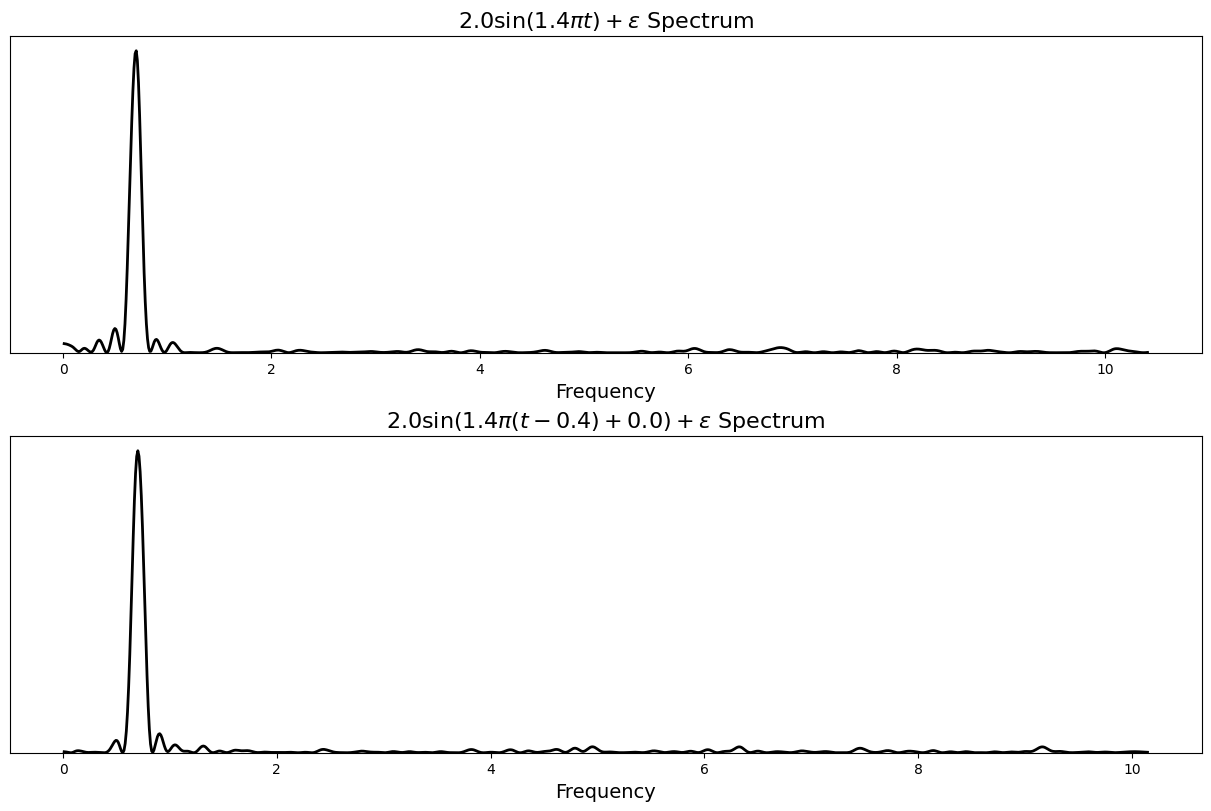

In [35]:
dataset1.plot_spectrum(method='ls'); # Lomb Scargle

## MOSM Model

### Model 1: No initialisation

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[0.71634243] [0.97796873]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[1.e-08]] [[1.e-08]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.08669888]] [[0.8142917 ]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.0000001 1.0000001]


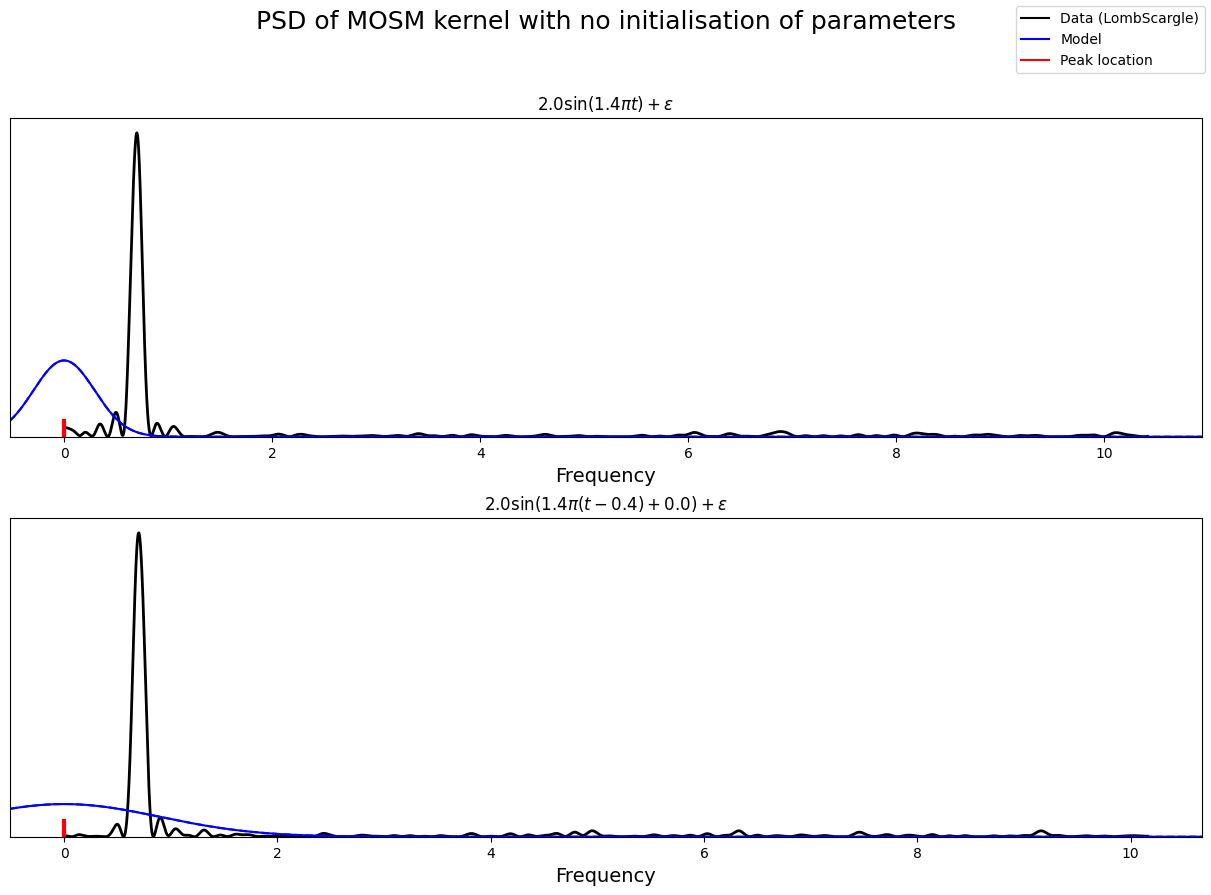

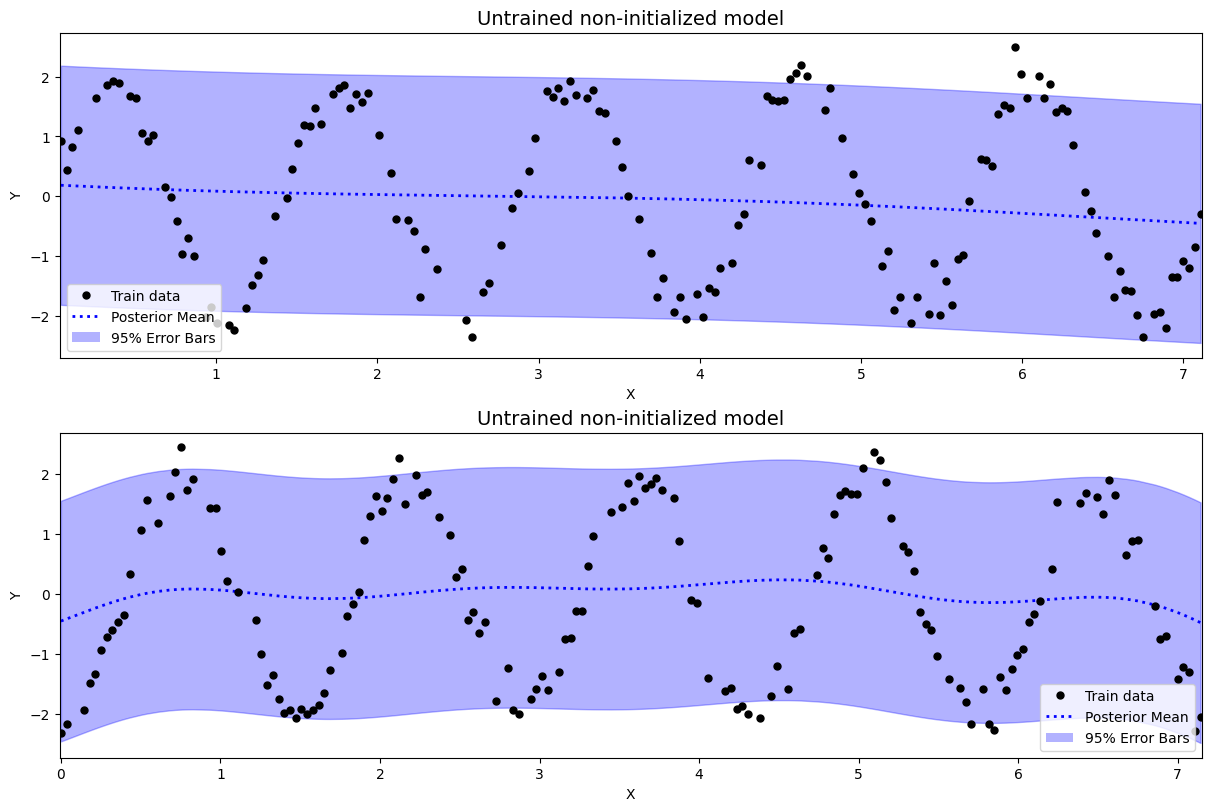

In [36]:
model1 = mogptk.MOSM(dataset1, Q=num_components)
model1.print_parameters()
model1.plot_spectrum(title='PSD of MOSM kernel with no initialisation of parameters');
model1.plot_prediction(title='Untrained non-initialized model');

### Model 2: Initialised Model

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.89001922] [19.84022909]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[0.69935594]] [[0.69935594]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00267952]] [[0.00282901]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.42787378 1.42403541]


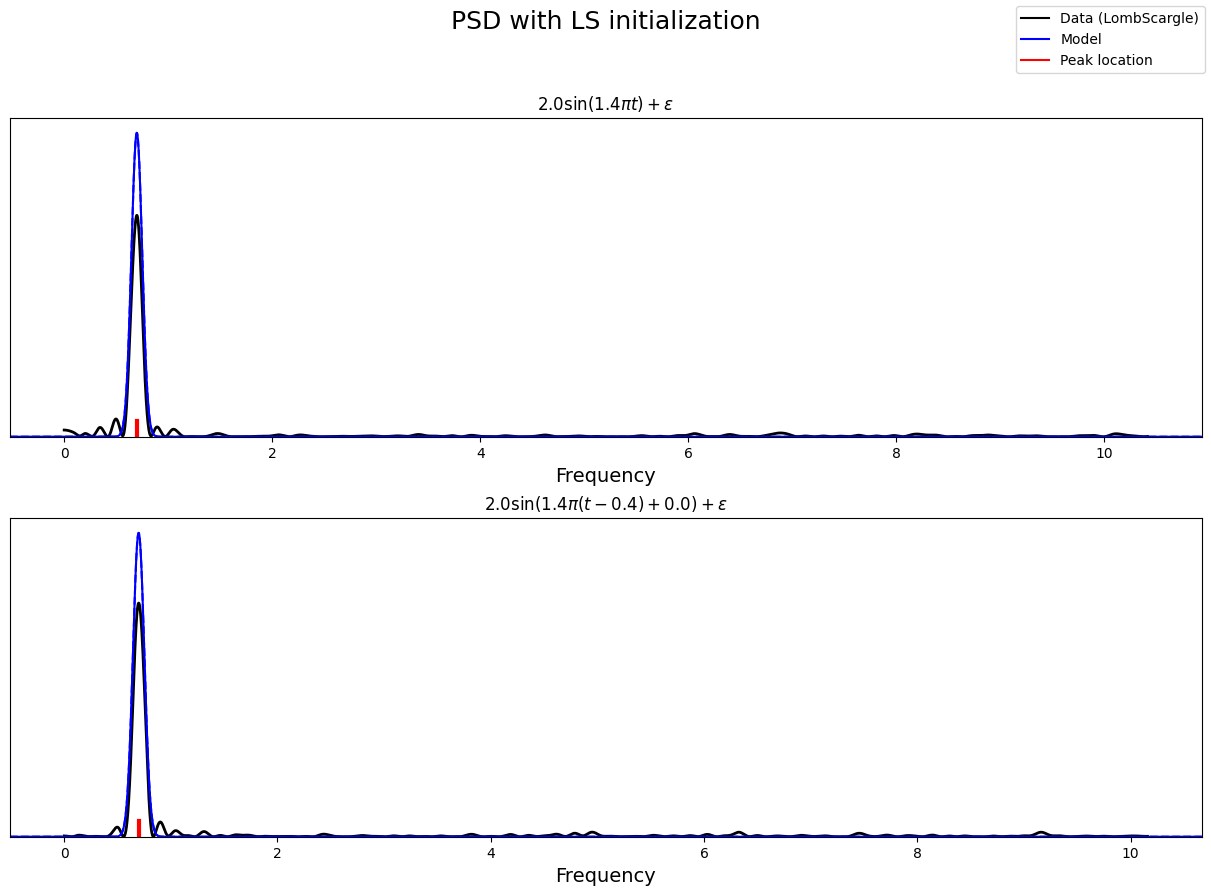

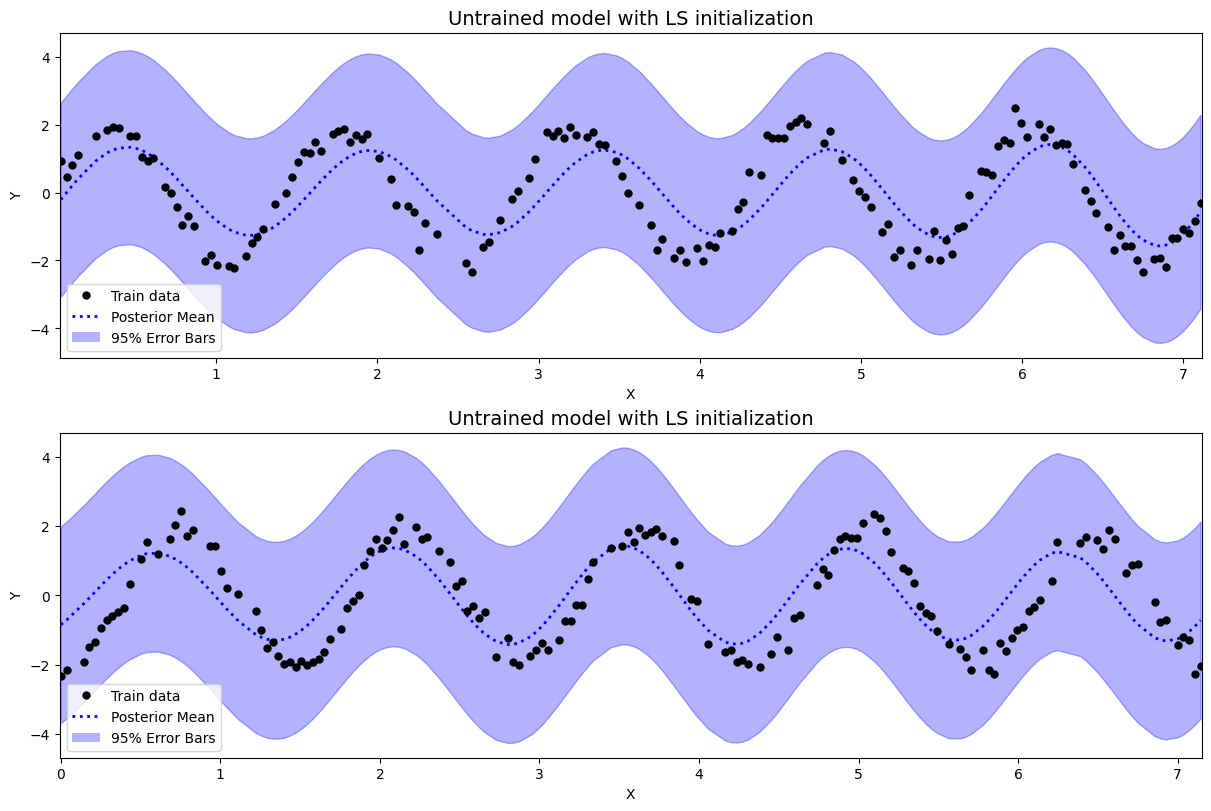

In [37]:
model2 = mogptk.MOSM(dataset1, Q=num_components)
model2.init_parameters(method='LS', iters=500)
model2.print_parameters()
model2.plot_spectrum(title='PSD with LS initialization');
model2.plot_prediction(title='Untrained model with LS initialization');

### Model 3: Trained Model

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 12
‣ Training points: 309
‣ Iterations: 1000


/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/mogptk/model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(self.gpr.loss())


     0/1000   0:00:02  loss=     481.107  error=    0.776733 (warmup)
   735/1000   0:00:10  loss=     390.341  error=    0.198789
  1000/1000   0:00:12  loss=     382.913  error=    0.198808
Optimization finished in 12.902 seconds


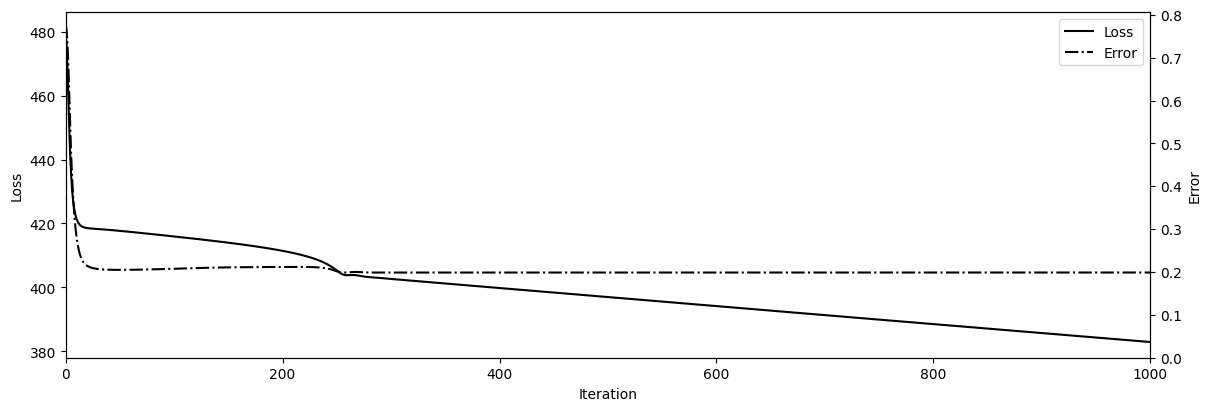

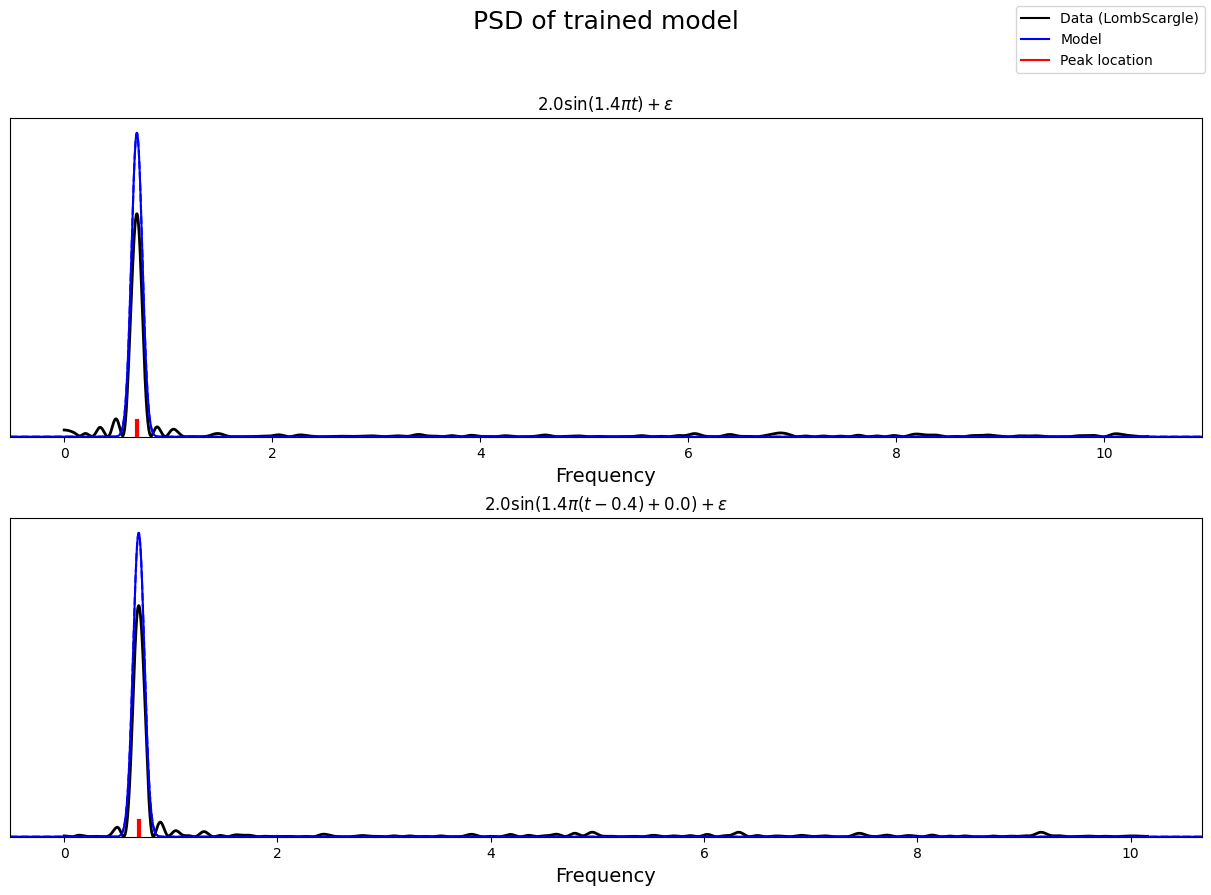

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.29435383] [19.06494483]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[0.69995417]] [[0.69993197]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00271627]] [[0.00276828]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.0814872]] [[-0.0814872]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.08448434] [-0.08448434]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.29935783 1.29562962]


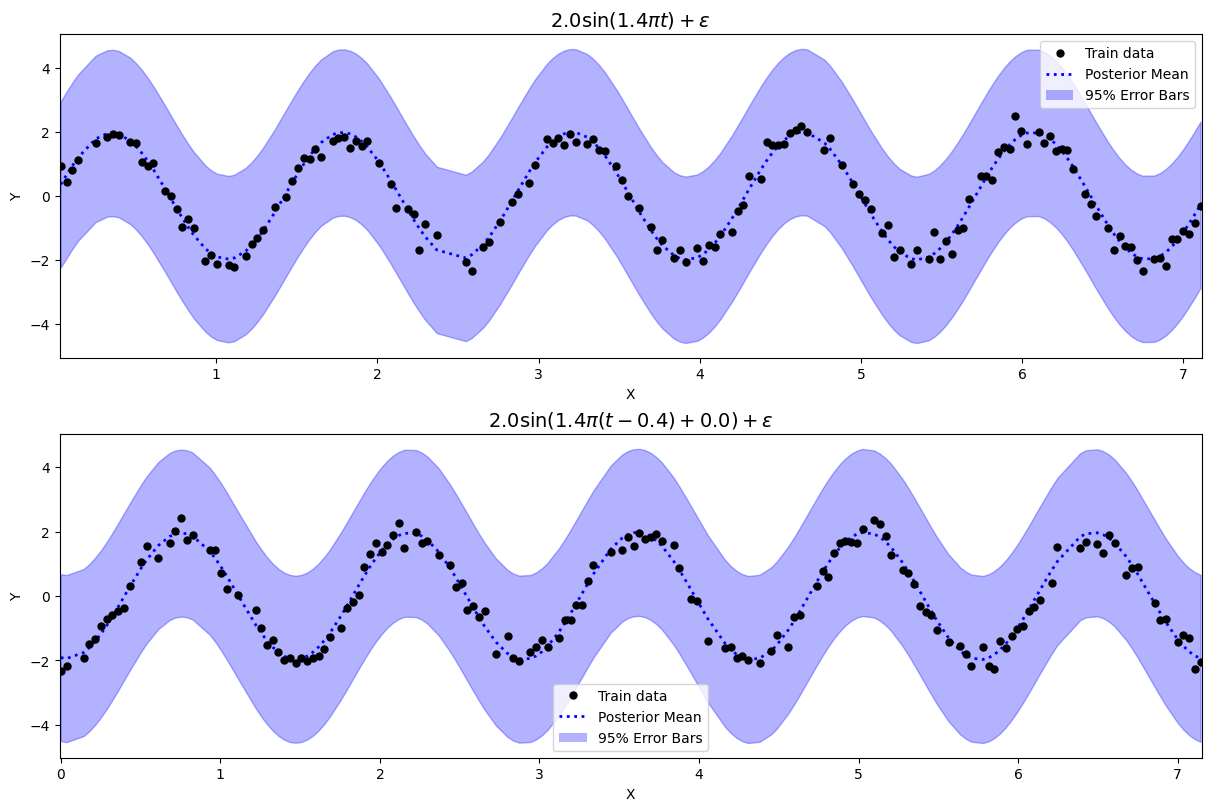

In [38]:
model3 = mogptk.MOSM(dataset1, Q=num_components)
model3.init_parameters(method='LS', iters=500)
model3.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model3.plot_spectrum(title='PSD of trained model');
model3.plot_prediction();
model3.print_parameters()

### Model 4: Retrain with delay parameter $\theta_{12}$ fixed at zero

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 309
‣ Iterations: 1000
     0/1000   0:00:00  loss=     481.107  error=    0.776733 (warmup)
   909/1000   0:00:10  loss=     385.449  error=    0.198755
  1000/1000   0:00:11  loss=     382.898  error=    0.198759
Optimization finished in 11.010 seconds


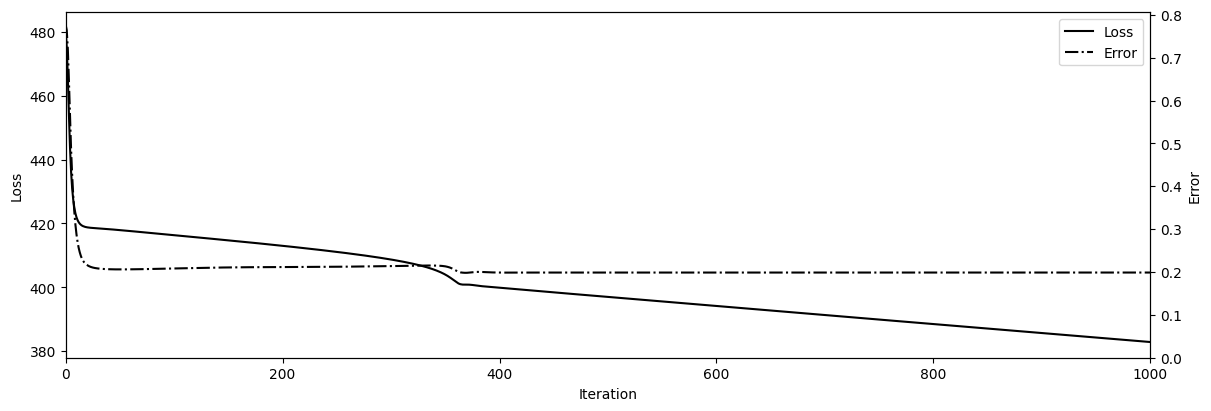

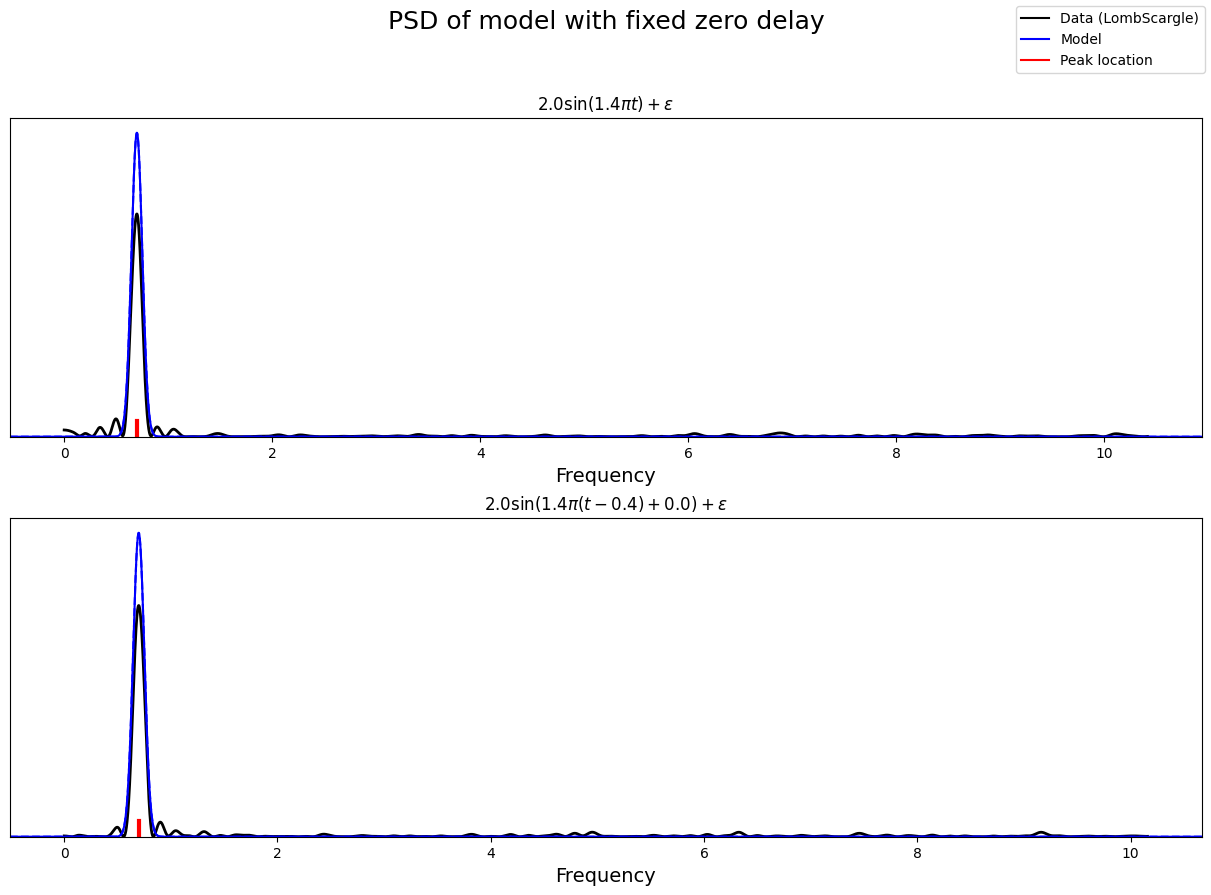

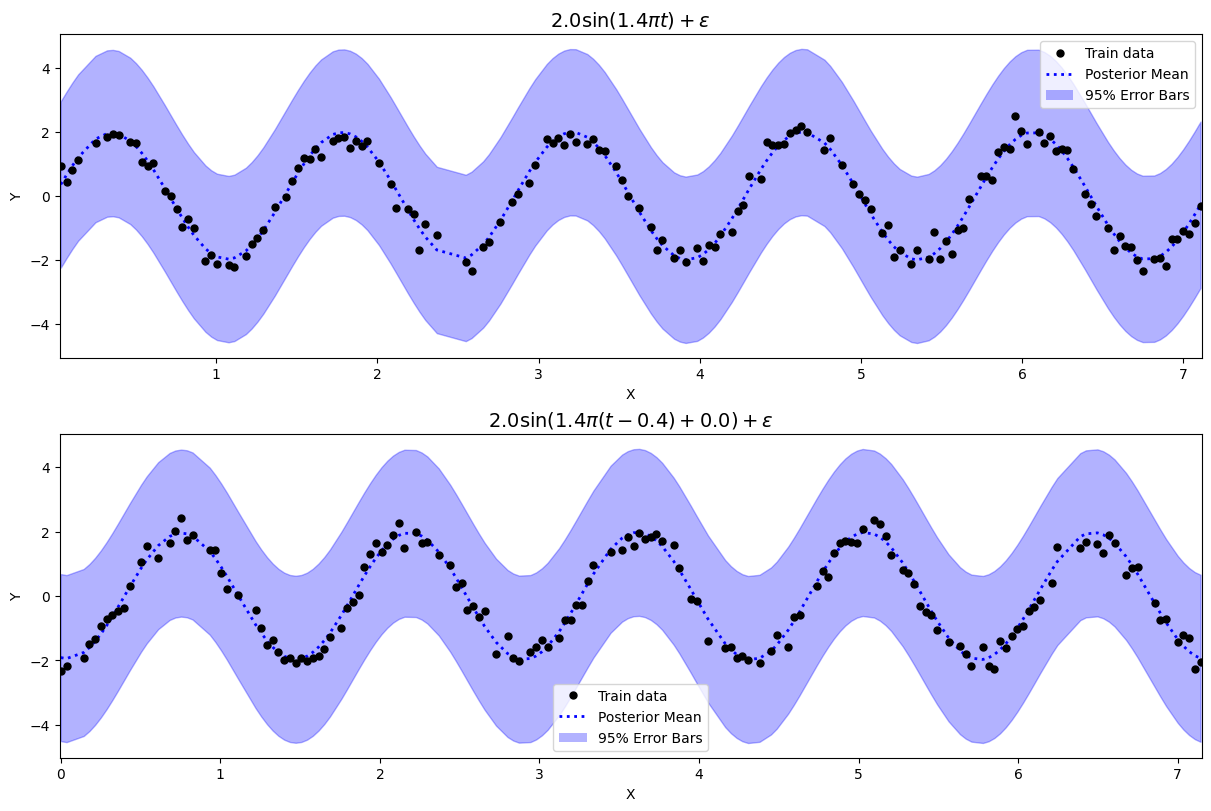

In [39]:
model4 = mogptk.MOSM(dataset1, Q=num_components)
model4.gpr.kernel.delay.assign(np.zeros((num_bands,num_components)), lower=0, upper=0, train=False)
model4.init_parameters(method='LS', iters=500)
model4.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model4.plot_spectrum(title='PSD of model with fixed zero delay');
model4.plot_prediction();

### Model 5: Retrain with phase parameter $\phi_{12}$ fixed at zero

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 309
‣ Iterations: 1000
     0/1000   0:00:00  loss=     481.107  error=    0.776733 (warmup)
  1000/1000   0:00:09  loss=      382.94  error=    0.198861
Optimization finished in 9.312 seconds


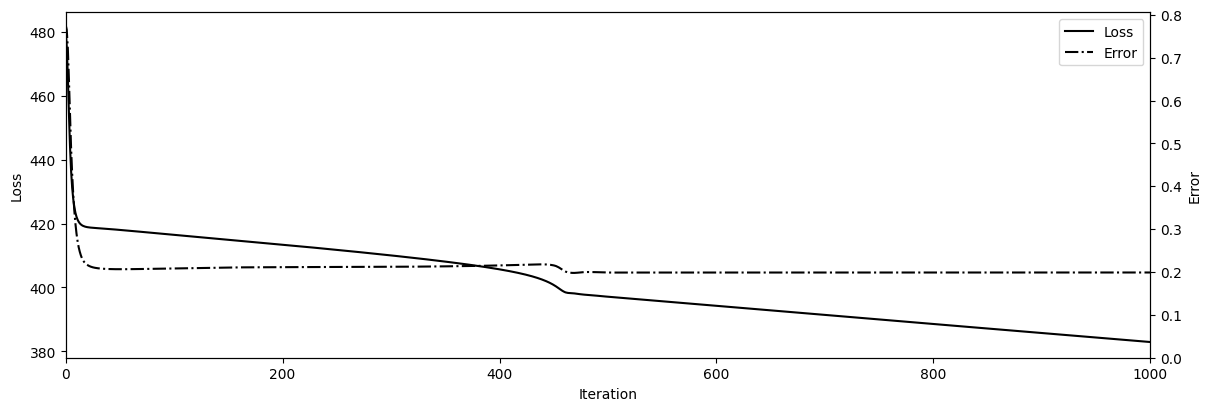

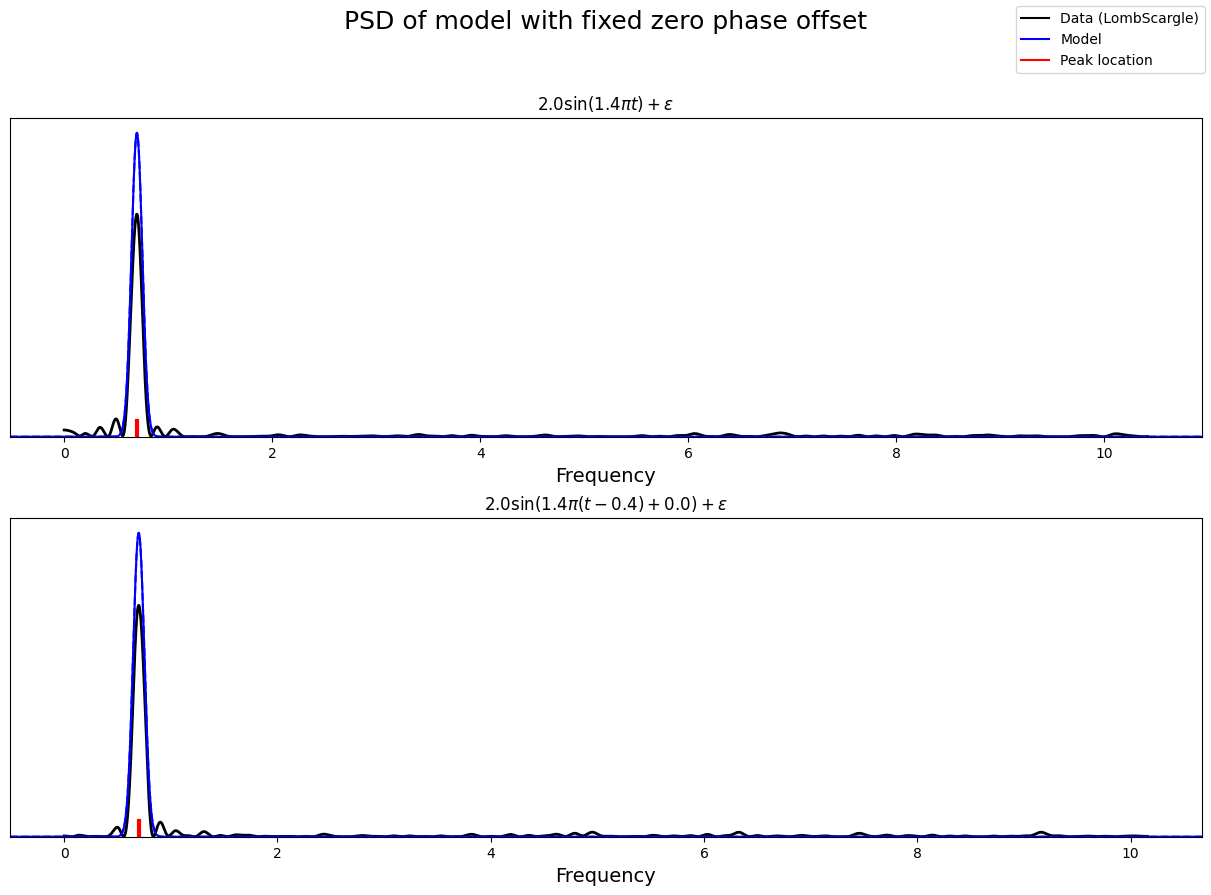

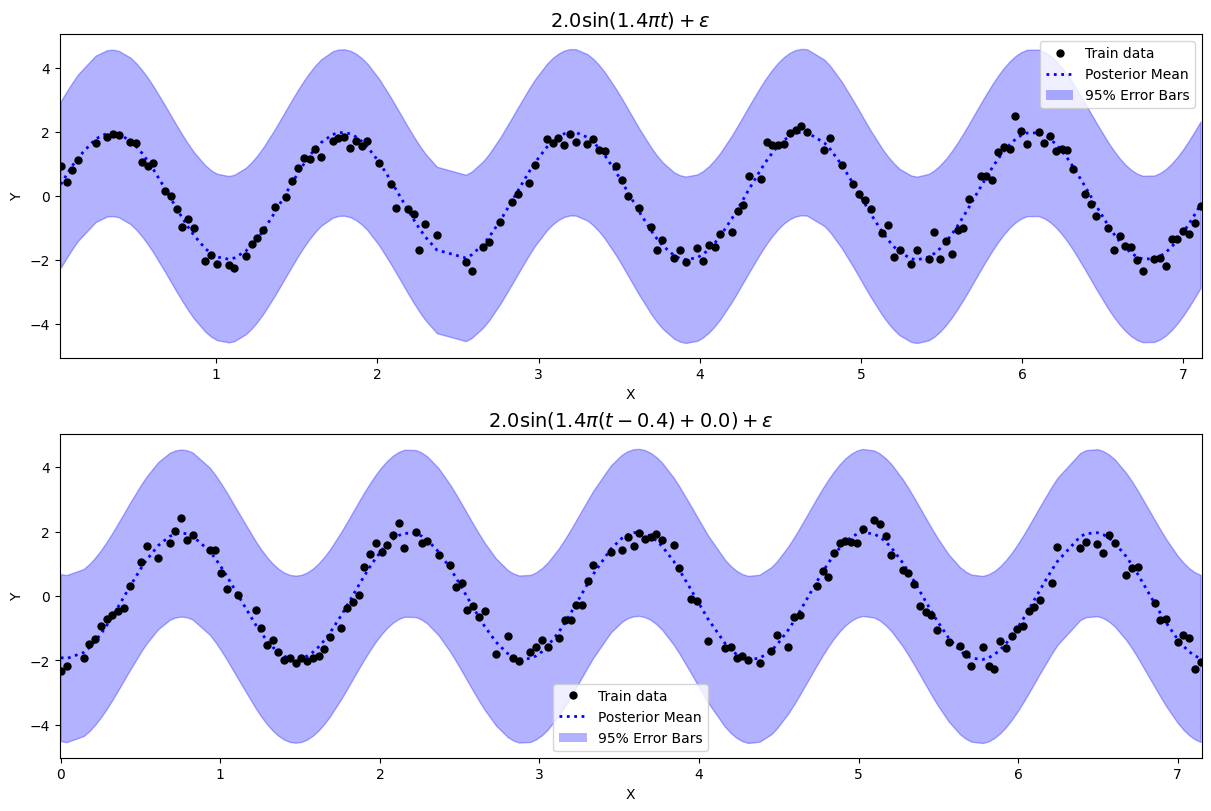

In [18]:
model5 = mogptk.MOSM(dataset1, Q=num_components)
model5.gpr.kernel.phase.assign(np.zeros((num_bands, num_components)), lower=0, upper=0, train=False)
model5.init_parameters(method='LS', iters=500)
model5.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model5.plot_spectrum(title='PSD of model with fixed zero phase offset');
model5.plot_prediction();

### Model 6: Retrain with $\phi_{12} = 0$ and $\Sigma_1 = \Sigma_2 = 0.02$

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 6
‣ Training points: 309
‣ Iterations: 1000
     0/1000   0:00:00  loss=     497.267  error=    0.995703 (warmup)
  1000/1000   0:00:08  loss=     378.531  error=    0.200792
Optimization finished in 8.977 seconds


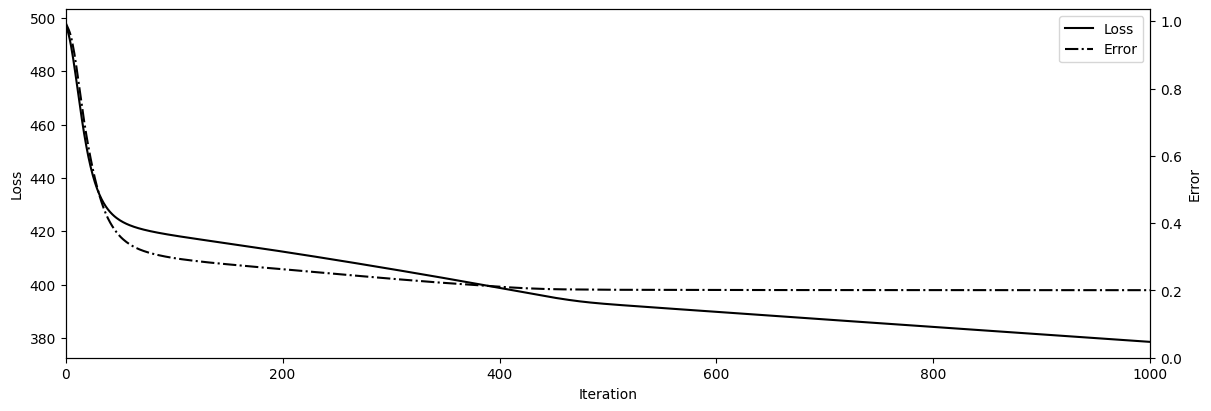

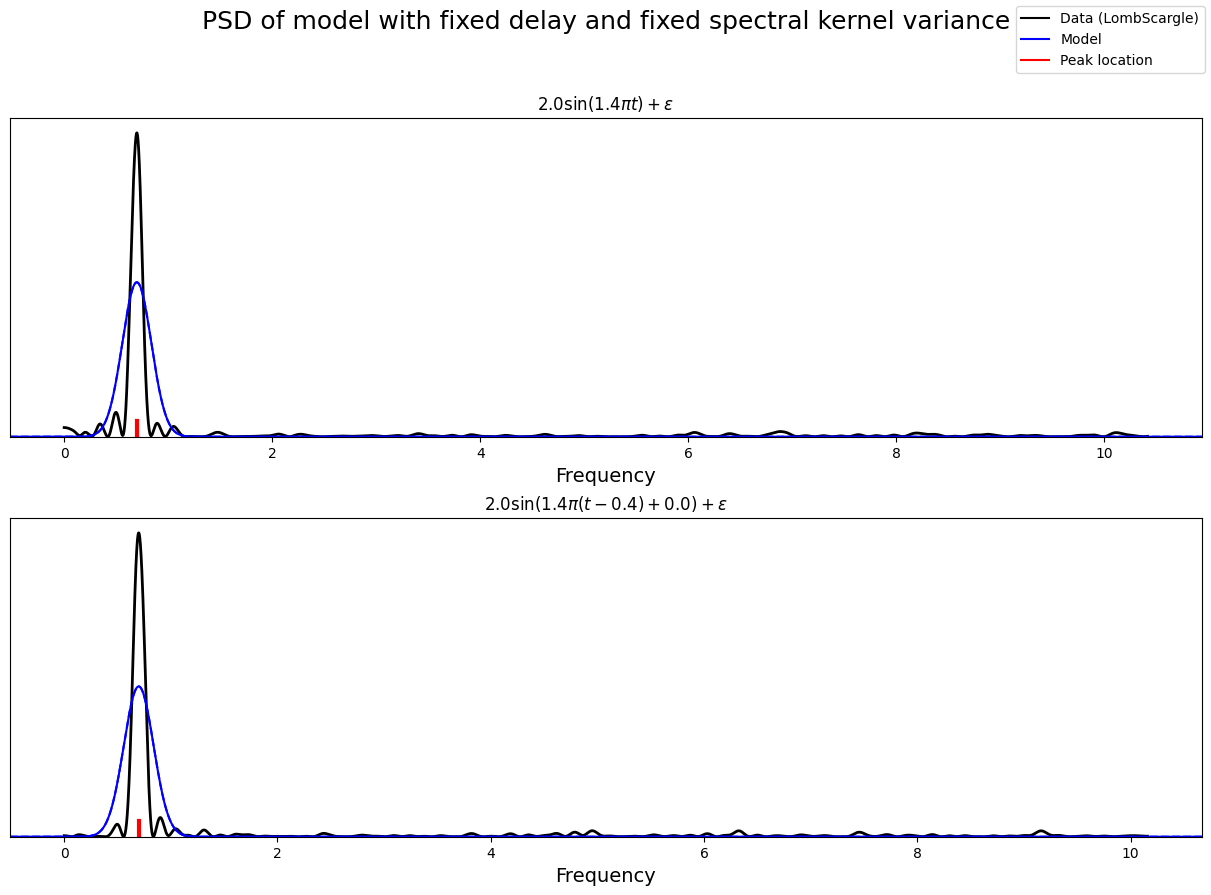

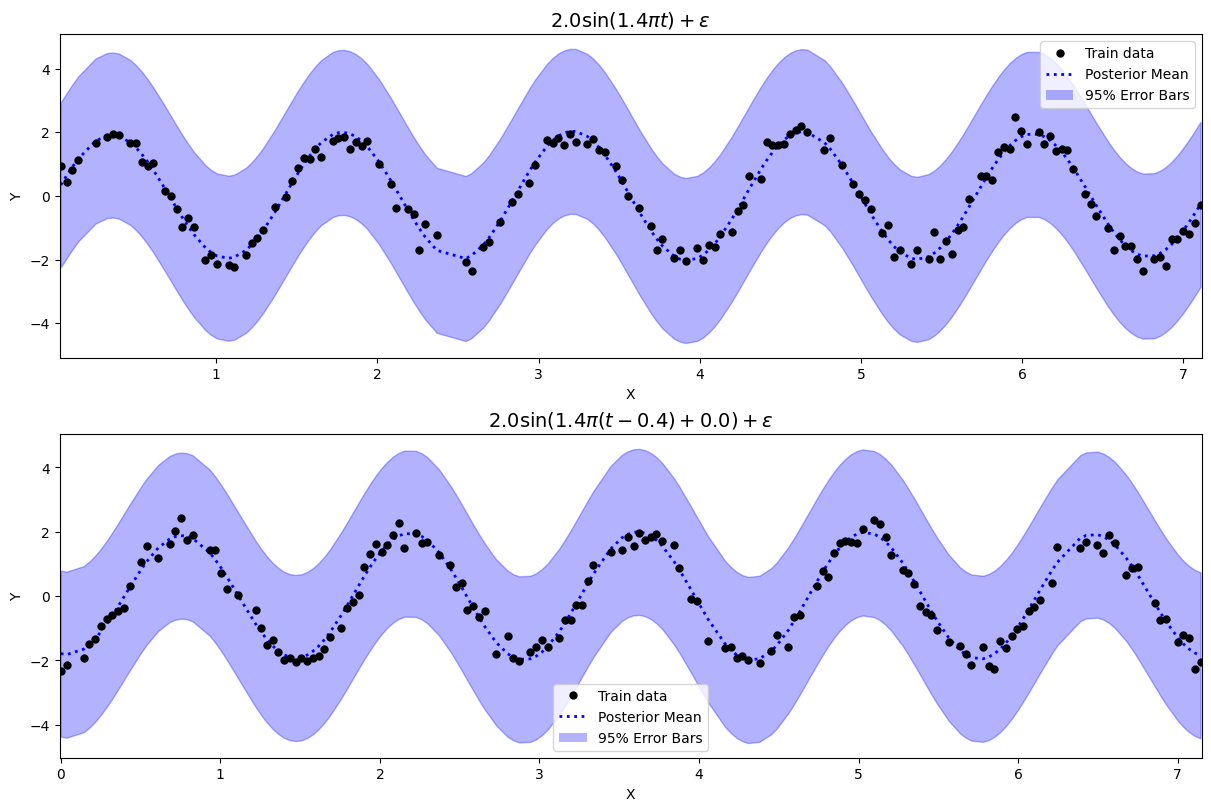

In [23]:
model6 = mogptk.MOSM(dataset1, Q=num_components)
model6.init_parameters(method='LS', iters=500)
model6.gpr.kernel.phase.assign(np.zeros((num_bands, num_components)), lower=0, upper=0, train=False)
model6.gpr.kernel.variance.assign(np.array([[0.02], [0.02]]), lower=0.016, upper=0.022, train=False)
model6.gpr.kernel.weight.assign(np.array([[2.2], [2.1]]), lower=2, upper=3, train=False)
model6.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model6.plot_spectrum(title='PSD of model with fixed delay and fixed spectral kernel variance');
model6.plot_prediction();

In [24]:
model6.print_parameters();

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,fixed,[[2.15677461] [2.12049092]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[0.69945364]] [[0.69971837]]]
MultiOutputSpectralMixtureKernel.variance,fixed,[[[0.01953444]] [[0.01955605]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.20227562]] [[-0.20227562]]]
MultiOutputSpectralMixtureKernel.phase,fixed,[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.29521668 1.291168 ]


In [25]:
model5.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.28070708] [19.04958839]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[0.70024624]] [[0.70022665]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00270801]] [[0.00277444]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.20214165]] [[-0.20214165]]]
MultiOutputSpectralMixtureKernel.phase,fixed,[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.29929276 1.29555973]


## Compare results

### Model 4: $\theta_{12}$ fixed at zero, fitting phase shift $\phi_{12}$

Data generating process: $A \sin(2\pi f[t - \textrm{delay}]) = 2.0 \sin(2\pi[0.7t - 0.28])$

Expecting $\phi_1 - \phi_2 = \phi_{12} = 0.28$

In [41]:
model4.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.30067702] [19.05250334]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[0.70012103]] [[0.70010056]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00271292]] [[0.00277068]]]
MultiOutputSpectralMixtureKernel.delay,fixed,[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.14149635] [-0.14149635]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.29929889 1.29555886]


### Model 5: $\phi_{12}$ fixed at zero, fitting delay $\theta_{12}$

Data generating process: $A \sin(2\pi f[ t - \textrm{delay}]) = 2.0 \sin(2\pi (0.7)[t - 0.4])$

Expecting $\theta_1 - \theta_2 = \theta_{12} = 0.4$

In [42]:
model5.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.28070708] [19.04958839]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 13.930000000000444]",[[[0.70024624]] [[0.70022665]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00270801]] [[0.00277444]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.20214165]] [[-0.20214165]]]
MultiOutputSpectralMixtureKernel.phase,fixed,[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.29929276 1.29555973]


## Correlation between bands

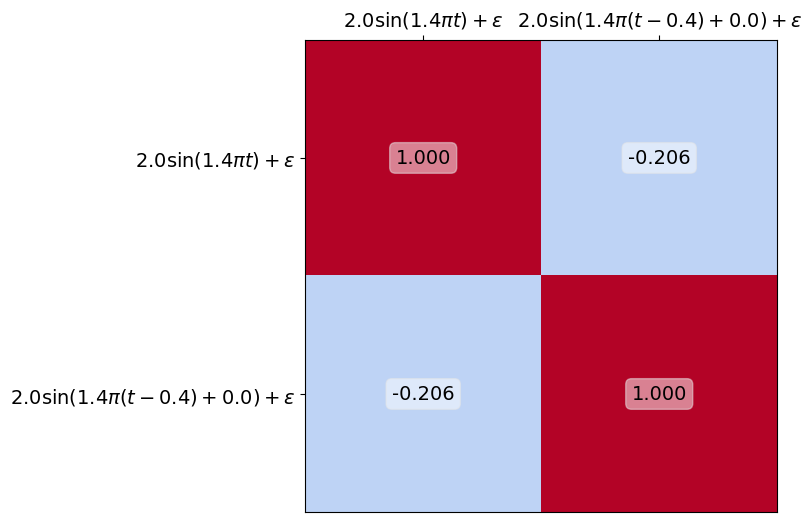

In [43]:
model5.plot_correlation(figsize=(8,8));

In [44]:
np.corrcoef(y1, y2)

array([[ 1.        , -0.21017153],
       [-0.21017153,  1.        ]])

Simple comparison of correlations between the bands in the ground truth data and the fitted data are close.